In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "enhanced_house_price_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (2000, 16)


In [3]:
target = "Price"

X = df.drop(columns=target)
y = df[target]

print("One observation:")
display(df.iloc[[0]])

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)

One observation:


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350



Feature columns:
['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant', 'Locality Rating']

Target: Price
X shape: (2000, 15)
y shape: (2000,)


In [4]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== HEAD ===")
display(df.head())

print("\n=== INFO ===")
df.info()

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

print("\n=== MISSING VALUES ===")
display(df.isna().sum())

print("\n=== DUPLICATES ===")
print(df.duplicated().sum())

=== SHAPE ===
(2000, 16)

=== HEAD ===


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676



=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area              2000 non-null   int64
 1   Bedrooms          2000 non-null   int64
 2   Bathrooms         2000 non-null   int64
 3   Stories           2000 non-null   int64
 4   Parking           2000 non-null   int64
 5   Age               2000 non-null   int64
 6   City              2000 non-null   str  
 7   Furnishing        2000 non-null   str  
 8   Main Road         2000 non-null   str  
 9   Guest Room        2000 non-null   str  
 10  Basement          2000 non-null   str  
 11  Water Supply      2000 non-null   str  
 12  Air Conditioning  2000 non-null   str  
 13  Preferred Tenant  2000 non-null   str  
 14  Locality Rating   2000 non-null   int64
 15  Price             2000 non-null   int64
dtypes: int64(8), str(8)
memory usage: 333.6 KB

=== DESCRIPTIVE STATISTICS ===


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06



=== MISSING VALUES ===


Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64


=== DUPLICATES ===
0


In [5]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'Locality Rating']

Categorical features:
['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant']


In [6]:
invalid_checks = {
    "Area <= 0": (df["Area"] <= 0).sum(),
    "Bedrooms <= 0": (df["Bedrooms"] <= 0).sum(),
    "Bathrooms <= 0": (df["Bathrooms"] <= 0).sum(),
    "Stories <= 0": (df["Stories"] <= 0).sum(),
    "Parking < 0": (df["Parking"] < 0).sum(),
    "Age < 0": (df["Age"] < 0).sum(),
    "Locality Rating < 0": (df["Locality Rating"] < 0).sum(),
    "Locality Rating > 10": (df["Locality Rating"] > 10).sum(),
    "Price <= 0": (df["Price"] <= 0).sum()
}

invalid_df = pd.Series(invalid_checks, name="Invalid count")

display(invalid_df.to_frame())

,Invalid count
Area <= 0,0
Bedrooms <= 0,0
Bathrooms <= 0,0
Stories <= 0,0
Parking < 0,0
Age < 0,0
Locality Rating < 0,0
Locality Rating > 10,0
Price <= 0,0


In [7]:
outlier_counts = {}

for col in numerical_features + ["Price"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_df = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Outlier count"]
)

display(outlier_df)

,Outlier count
Area,0
Bedrooms,0
Bathrooms,0
Stories,0
Parking,0
Age,0
Locality Rating,0
Price,7


In [8]:
skewness = df[numerical_features + ["Price"]].skew().sort_values(ascending=False)

display(skewness.to_frame("Skewness"))

,Skewness
Locality Rating,0.055934
Age,0.048395
Parking,0.017242
Stories,0.007311
Price,-0.004797
Area,-0.015810
Bathrooms,-0.039345
Bedrooms,-0.050423


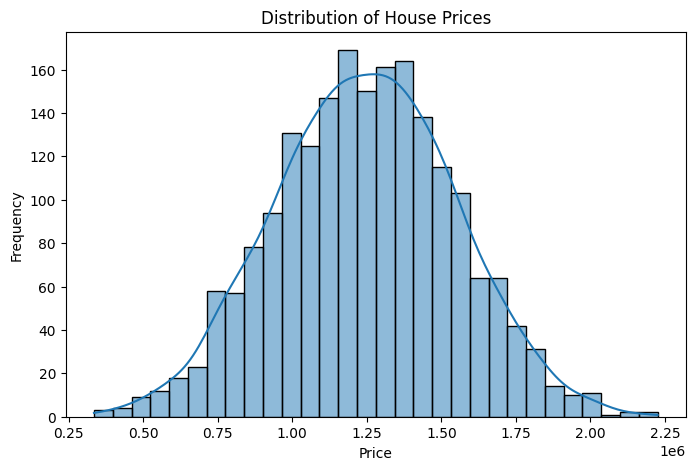

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

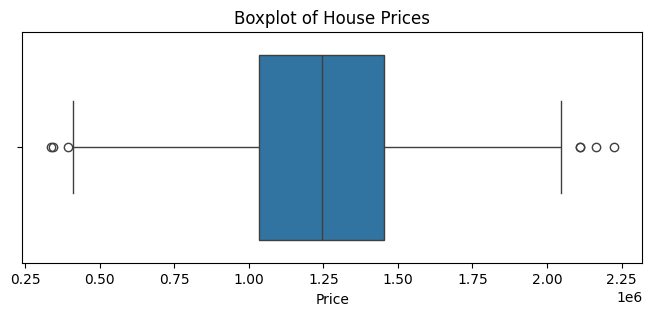

In [10]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["Price"])

plt.title("Boxplot of House Prices")
plt.xlabel("Price")
plt.show()

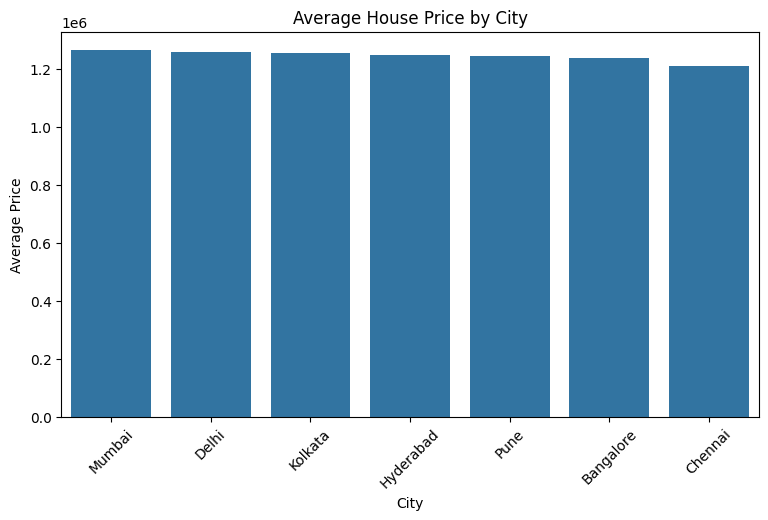

In [11]:
city_price = (
    df.groupby("City")["Price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=city_price.index,
    y=city_price.values
)

plt.title("Average House Price by City")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

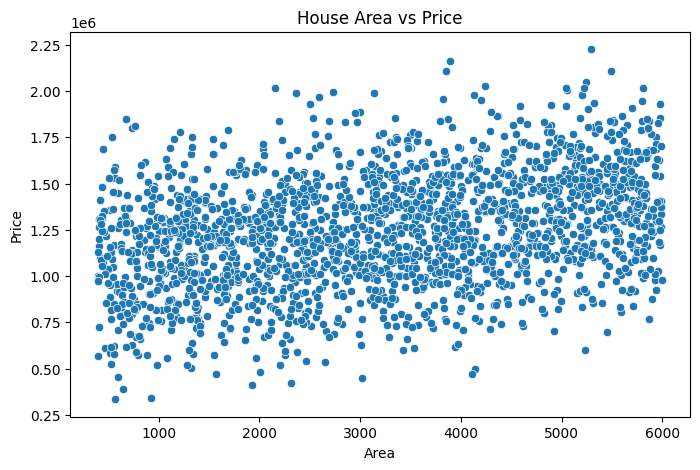

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Area",
    y="Price"
)

plt.title("House Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

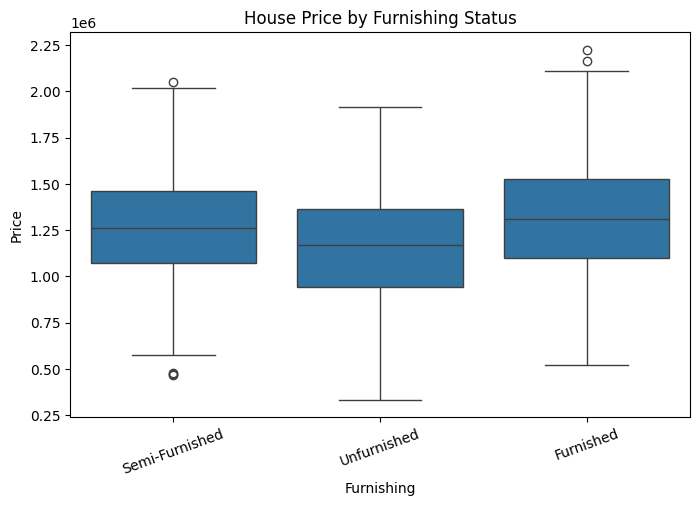

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Furnishing",
    y="Price"
)

plt.title("House Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price")
plt.xticks(rotation=20)
plt.show()

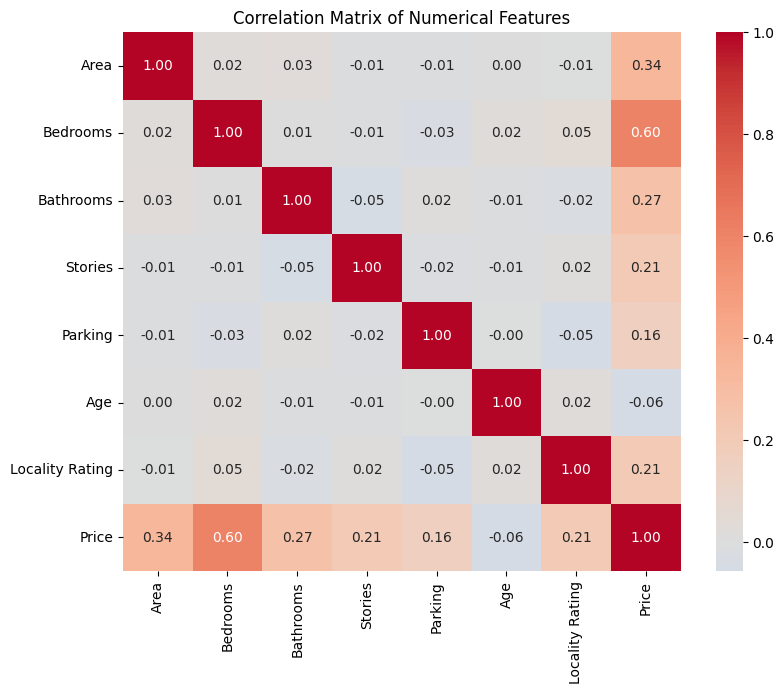

In [14]:
correlation = df[numerical_features + ["Price"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [15]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'Locality Rating']

Categorical features:
['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant']

Number of numerical features: 7
Number of categorical features: 8


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [17]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Split temporary set into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1400, 15) (1400,)
Validation: (300, 15) (300,)
Test: (300, 15) (300,)


In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (1400, 31)
Processed validation shape: (300, 31)
Processed test shape: (300, 31)


In [19]:
print("=== MODEL INPUT ===")
print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

print("\nData type:", X_train_processed.dtype)

=== MODEL INPUT ===
X_train_processed shape: (1400, 31)
X_val_processed shape: (300, 31)
X_test_processed shape: (300, 31)

Data type: float64


In [20]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}

In [21]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[name] = model

print("Training completed.")

for name, model in trained_models.items():
    print(f"{name}: trained")

Training completed.
Linear Regression: trained
Ridge: trained
Decision Tree: trained
Random Forest: trained
Gradient Boosting: trained


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

validation_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_val_processed)

    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)

    validation_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    })

validation_results = pd.DataFrame(validation_results)

display(validation_results.sort_values("RMSE"))

,Model,MAE,MSE,RMSE,R²
1,Ridge,115895.284453,2.164648e+10,147127.418627,0.756293
0,Linear Regression,115921.994226,2.165715e+10,147163.691625,0.756173
4,Gradient Boosting,126717.840789,2.462584e+10,156926.236201,0.722750
3,Random Forest,134924.783333,2.926706e+10,171076.193288,0.670497
2,Decision Tree,217223.736667,7.146630e+10,267331.819714,0.195396


In [23]:
best_model_name = validation_results.loc[
    validation_results["RMSE"].idxmin(),
    "Model"
]

best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print("Validation RMSE:", validation_results.loc[
    validation_results["RMSE"].idxmin(), "RMSE"
])

Best model: Ridge
Validation RMSE: 147127.41862706642


In [24]:
y_test_pred = best_model.predict(X_test_processed)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

test_results = pd.DataFrame([{
    "Model": best_model_name,
    "MAE": test_mae,
    "MSE": test_mse,
    "RMSE": test_rmse,
    "R²": test_r2
}])

display(test_results)

,Model,MAE,MSE,RMSE,R²
0,Ridge,117323.294731,2.126660e+10,145830.730431,0.746486


In [25]:
errors = y_test - y_test_pred

error_analysis = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_test_pred,
    "Error": errors,
    "Absolute Error": np.abs(errors)
})

display(error_analysis.head())

print("Mean Error:", errors.mean())
print("Mean Absolute Error:", np.abs(errors).mean())
print("Maximum Absolute Error:", np.abs(errors).max())

,Actual Price,Predicted Price,Error,Absolute Error
771,905578,9.896090e+05,-84030.971094,84030.971094
1788,1489794,1.512491e+06,-22697.171250,22697.171250
1106,1466245,1.385820e+06,80424.858119,80424.858119
787,1122197,1.067248e+06,54949.067740,54949.067740
785,1296671,1.427673e+06,-131002.448145,131002.448145


Mean Error: 13482.953435035995
Mean Absolute Error: 117323.29473145395
Maximum Absolute Error: 460316.5015009844


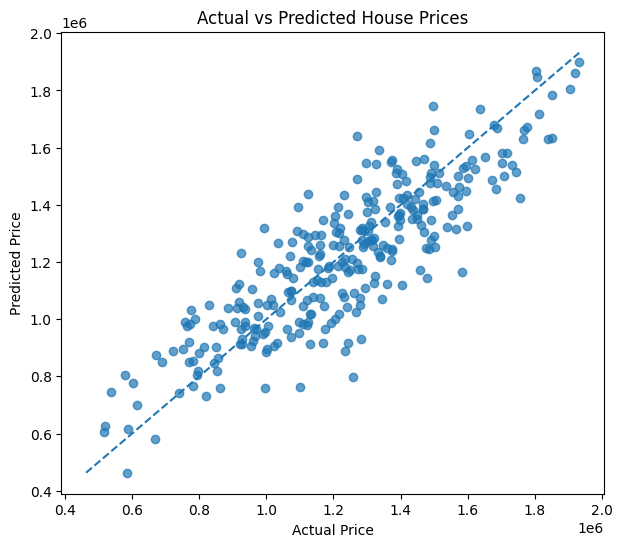

In [26]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_test_pred, alpha=0.7)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

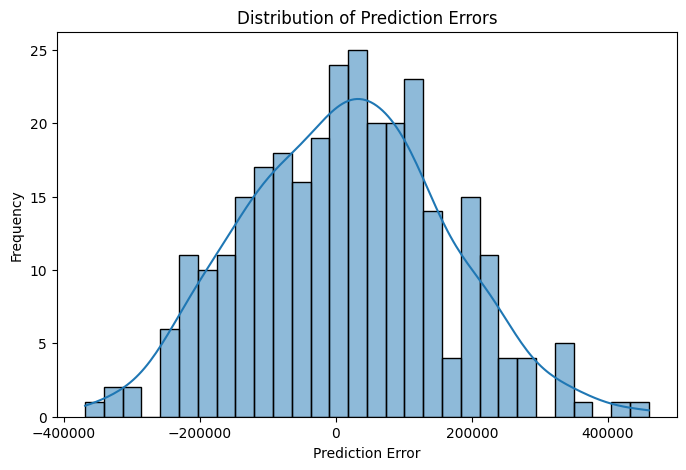

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(errors, bins=30, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

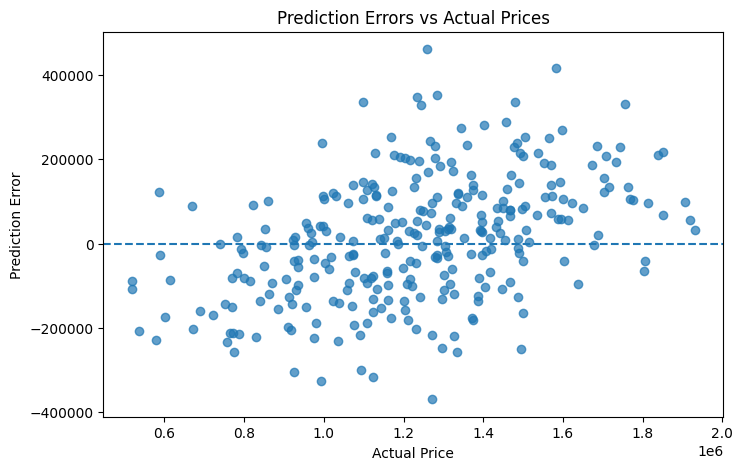

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, errors, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.title("Prediction Errors vs Actual Prices")
plt.xlabel("Actual Price")
plt.ylabel("Prediction Error")
plt.show()

In [29]:
import joblib
import os

MODEL_DIR = "saved_model"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(MODEL_DIR, "house_price_model.pkl"))
joblib.dump(preprocessor, os.path.join(MODEL_DIR, "preprocessor.pkl"))

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [30]:
loaded_model = joblib.load(
    os.path.join(MODEL_DIR, "house_price_model.pkl")
)

loaded_preprocessor = joblib.load(
    os.path.join(MODEL_DIR, "preprocessor.pkl")
)

# Transform test data using the saved preprocessor
X_test_loaded = loaded_preprocessor.transform(X_test)

# Predict using the saved model
loaded_predictions = loaded_model.predict(X_test_loaded)

print("Loaded model:", type(loaded_model).__name__)
print("Loaded preprocessor:", type(loaded_preprocessor).__name__)
print("Prediction sample:", loaded_predictions[:5])

Loaded model: Ridge
Loaded preprocessor: ColumnTransformer
Prediction sample: [ 989608.97109359 1512491.17124955 1385820.14188115 1067247.93226003
 1427673.44814516]


In [31]:
print(
    "Predictions identical:",
    np.allclose(y_test_pred, loaded_predictions)
)

Predictions identical: True


In [32]:
sample_input = X_test.iloc[[0]]

sample_processed = loaded_preprocessor.transform(sample_input)
sample_prediction = loaded_model.predict(sample_processed)[0]

print("Sample input:")
display(sample_input)

print("\nProcessed input shape:", sample_processed.shape)
print("Predicted price:", sample_prediction)

Sample input:


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating
771,4930,1,3,2,0,9,Chennai,Semi-Furnished,Yes,No,No,Both,No,Family,2



Processed input shape: (1, 31)
Predicted price: 989608.971093586


In [33]:
def predict_house_price(input_data):
    input_df = pd.DataFrame([input_data])

    processed_data = loaded_preprocessor.transform(input_df)
    prediction = loaded_model.predict(processed_data)[0]

    return prediction


prediction = predict_house_price(sample_input.iloc[0].to_dict())

print("Predicted price:", prediction)

Predicted price: 989608.971093586


In [34]:
print("API input features:")

for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

print("\nTotal input features:", len(X.columns))

API input features:
1. Area
2. Bedrooms
3. Bathrooms
4. Stories
5. Parking
6. Age
7. City
8. Furnishing
9. Main Road
10. Guest Room
11. Basement
12. Water Supply
13. Air Conditioning
14. Preferred Tenant
15. Locality Rating

Total input features: 15
